# PHYS 142 — Assignment 1: Harmonic-oscillator path integral
Units $m=\omega=\hbar=1$. Run top to bottom; figures go to `figs/`, the animation to `animation.gif`, autograded numbers to `results.json`.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

TSN = "212345678"                      # <-- put your Triton Student Number here (9 digits, starts with 2)
assert len(TSN) == 9 and TSN.isdigit() and TSN[0] == "2", "TSN must be 9 digits starting with 2"
x_start = (-1) ** int(TSN[-3]) * (0.5 + int(TSN[-2:]) / 200)   # sign from 3rd-to-last digit, size from last two
T0, alpha = 2 * np.pi, 2.0
print(f"x_start = {x_start:+.3f}")
R = {"xstart": f"{x_start:+.3f}"}          # numbers exported to the LaTeX report

def kernel(x, t):
    """Exact HO propagator K(x_b, t; x_a, 0) as a matrix K[b, a]."""
    sn, cs = np.sin(t), np.cos(t)
    xb, xa = x[:, None], x[None, :]
    return np.exp(1j * ((xa**2 + xb**2) * cs - 2 * xa * xb) / (2 * sn)) / np.sqrt(2j * np.pi * sn)

def evolve(n_per_period=128, ND=600):
    """Return grid x, spacing dx and states psi[n, i] = Psi(x_i, n*eps), n = 0..n_per_period (no renormalization)."""
    x = np.linspace(-4, 4, ND + 1); dx = x[1] - x[0]
    U = kernel(x, T0 / n_per_period) * dx          # one-step update: psi -> dx * K_eps @ psi
    psi = np.empty((n_per_period + 1, ND + 1), complex)
    psi[0] = (alpha / np.pi) ** 0.25 * np.exp(-alpha / 2 * (x - x_start) ** 2)
    for n in range(len(psi) - 1):
        psi[n + 1] = U @ psi[n]
    return x, dx, psi

x_start = +0.890


## Problem A — $\mathcal K_{8\epsilon} = (\Delta x)^7\,\mathcal K_\epsilon^8$

In [2]:
x, dx, psi = evolve()                          # eps = T0/128, N_D = 600
K_eps = kernel(x, T0 / 128)
K_8eps = np.linalg.matrix_power(K_eps, 8) * dx**7
print(K_8eps)
# check: acting on psi_0, the composed propagator reproduces the exact one-shot propagator
R["Kerr"] = f"{np.abs(K_8eps @ psi[0] - kernel(x, T0 / 16) @ psi[0]).max() * dx:.1e}"
print("max |psi(T0/16): composed - exact| =", R["Kerr"])
with open("figs/K8eps.txt", "w") as f: print(K_8eps, file=f)

[[-0.05955846+0.0178667j  -0.0757611 +0.0217024j  -0.07967385+0.05414053j
  ... -0.46505982-0.30932634j -0.35439299-0.42735575j
  -0.21687407-0.50917202j]
 [-0.0757611 +0.0217024j  -0.0896081 +0.03330227j -0.08308486+0.06724787j
  ... -0.53404108-0.16837676j -0.46141968-0.31131639j
  -0.35439299-0.42735575j]
 [-0.07967385+0.05414053j -0.08308486+0.06724787j -0.06226964+0.09303051j
  ... -0.56407376-0.01040964j -0.53404108-0.16837676j
  -0.46505982-0.30932634j]
 ...
 [-0.46505982-0.30932634j -0.53404108-0.16837676j -0.56407376-0.01040964j
  ... -0.06226964+0.09303051j -0.08308486+0.06724787j
  -0.07967385+0.05414053j]
 [-0.35439299-0.42735575j -0.46141968-0.31131639j -0.53404108-0.16837676j
  ... -0.08308486+0.06724787j -0.0896081 +0.03330227j
  -0.0757611 +0.0217024j ]
 [-0.21687407-0.50917202j -0.35439299-0.42735575j -0.46505982-0.30932634j
  ... -0.07967385+0.05414053j -0.0757611 +0.0217024j
  -0.05955846+0.0178667j ]]
max |psi(T0/16): composed - exact| = 1.3e-04


## Problems B, C — $\langle x\rangle$, $\langle K\rangle$, $\langle V\rangle$, $\langle E\rangle$ vs $t$

norm in [0.999404, 1.000000];  <E> in [1.0179, 1.0214]  (exact 1.0211)


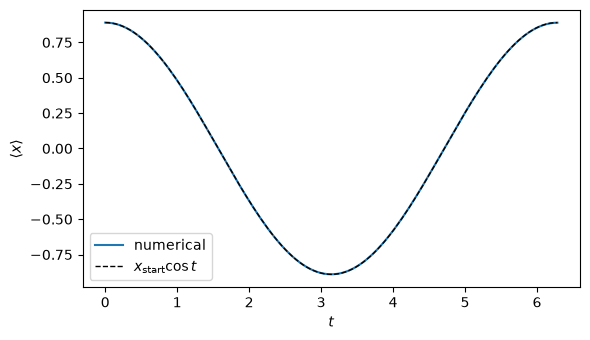

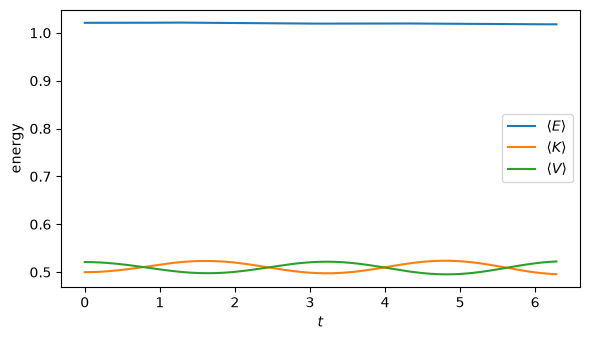

In [3]:
t = np.arange(len(psi)) * T0 / 128
P = np.abs(psi) ** 2
norm = P.sum(1) * dx                           # stays ~1; not renormalized (handout formulas used as written)
mean_x = (P * x).sum(1) * dx                   # <x> = int x P_t dx
V = (P * x**2 / 2).sum(1) * dx                 # <V> = int x^2/2 P_t dx
K = 0.5 * (np.abs(np.gradient(psi, dx, axis=1)) ** 2).sum(1) * dx   # <K> = 1/2 int |dPsi/dx|^2 dx
E = K + V
R.update(Nmin=f"{norm.min():.5f}", Emin=f"{E.min():.4f}", Emax=f"{E.max():.4f}", Eex=f"{(alpha + 1/alpha)/4 + x_start**2/2:.4f}")
print(f"norm in [{norm.min():.6f}, {norm.max():.6f}];  <E> in [{E.min():.4f}, {E.max():.4f}]"
      f"  (exact {(alpha + 1/alpha)/4 + x_start**2/2:.4f})")

plt.figure(figsize=(6, 3.5))
plt.plot(t, mean_x, label="numerical"); plt.plot(t, x_start * np.cos(t), "k--", lw=1, label=r"$x_{\rm start}\cos t$")
plt.xlabel("$t$"); plt.ylabel(r"$\langle x\rangle$"); plt.legend(); plt.tight_layout(); plt.savefig("figs/mean_x.pdf"); plt.show()

plt.figure(figsize=(6, 3.5))
for y, l in [(E, r"$\langle E\rangle$"), (K, r"$\langle K\rangle$"), (V, r"$\langle V\rangle$")]: plt.plot(t, y, label=l)
plt.xlabel("$t$"); plt.ylabel("energy"); plt.legend(); plt.tight_layout(); plt.savefig("figs/energy.pdf"); plt.show()

## Problem D — $\Psi_t$ and $P_t(x)$ at $t = mT_0/16$, $m=0,\dots,8$, with $V(x)$

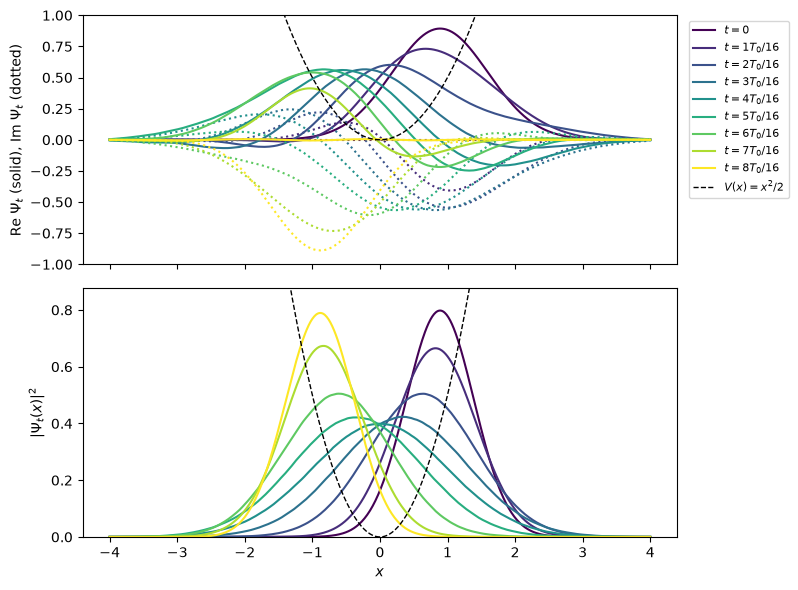

In [4]:
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
for m in range(9):
    kw = dict(color=plt.cm.viridis(m / 8), label=f"$t={m}T_0/16$" if m else "$t=0$")
    a1.plot(x, psi[8 * m].real, **kw); a1.plot(x, psi[8 * m].imag, ":", color=kw["color"])
    a2.plot(x, P[8 * m], **kw)
for a in (a1, a2): a.plot(x, x**2 / 2, "k--", lw=1, label="$V(x)=x^2/2$")
a1.set(ylabel=r"Re $\Psi_t$ (solid), Im $\Psi_t$ (dotted)", ylim=(-1, 1)); a2.set(xlabel="$x$", ylabel=r"$|\Psi_t(x)|^2$", ylim=(0, 1.1 * P.max()))
a1.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1)); fig.tight_layout(); fig.savefig("figs/snapshots.pdf"); plt.show()

## Problem E — animation (129 frames, one per $\epsilon$)

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, x**2 / 2, "k--", lw=1, label="$V(x)$")
lines = [ax.plot([], [], label=l)[0] for l in (r"$|\Psi|^2$", r"Re $\Psi$", r"Im $\Psi$")]
ax.set(xlim=(-4, 4), ylim=(-1, 1.2), xlabel="$x$"); ax.legend(loc="upper right")
def frame(n):
    for ln, y in zip(lines, (P[n], psi[n].real, psi[n].imag)): ln.set_data(x, y)
    ax.set_title(f"$t = {n}\\epsilon$"); return lines
FuncAnimation(fig, frame, frames=len(psi)).save("animation.gif", writer=PillowWriter(fps=20)); plt.close(fig)

## Problem F (bonus) — norm $\mathcal N(t)$ without renormalizing

eps = T0/16   N_D = 600:  N(T0) = 9.995e-01
eps = T0/512  N_D = 600:  N(T0) = 1.148e+258
eps = T0/128  N_D = 150:  N(T0) = 4.095e+51


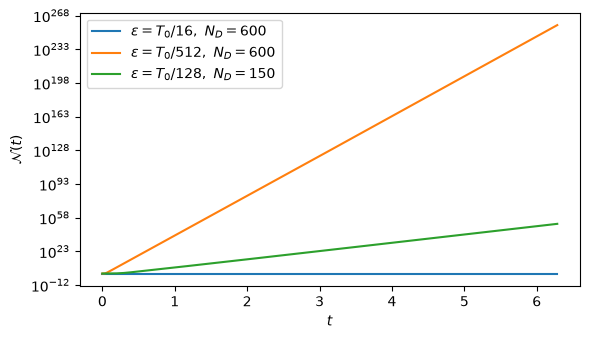

N_D = 600: smallest stable eps = T0/369 = 0.0170   (estimate 4*dx/pi = 0.0170)


N_D = 1200: smallest stable eps = T0/741 = 0.0085   (estimate 4*dx/pi = 0.0085)


In [6]:
np.seterr(over='ignore', invalid='ignore')   # unstable runs overflow on purpose
plt.figure(figsize=(6, 3.5))
for tag, n, ND in [("I", 16, 600), ("II", 512, 600), ("III", 128, 150)]:
    xx, d, ps = evolve(n, ND)
    N = (np.abs(ps) ** 2).sum(1) * d
    plt.semilogy(np.arange(n + 1) * T0 / n, N, label=rf"$\epsilon=T_0/{n},\ N_D={ND}$")
    m_, e_ = f"{N[-1]:.2e}".split("e"); R["Norm" + tag] = rf"{m_}\times10^{{{int(e_)}}}"
    print(f"eps = T0/{n:<3}  N_D = {ND}:  N(T0) = {N[-1]:.3e}")
plt.xlabel("$t$"); plt.ylabel(r"$\mathcal{N}(t)$"); plt.legend(); plt.tight_layout(); plt.savefig("figs/norm.pdf"); plt.show()

def stable(n, ND):   # norm stays within 1% over one period?
    return (np.abs(evolve(n, ND)[2]) ** 2).sum(1).max() * 8 / ND < 1.01
for ND in (600, 1200):
    lo, hi = 16, 4096                          # bisect for the largest stable n = T0/eps
    while hi - lo > 1:
        mid = (lo + hi) // 2; lo, hi = (mid, hi) if stable(mid, ND) else (lo, mid)
    R["nmax" + {600: "A", 1200: "B"}[ND]] = str(lo)
    print(f"N_D = {ND}: smallest stable eps = T0/{lo} = {T0/lo:.4f}   (estimate 4*dx/pi = {32/(np.pi*ND):.4f})")

## Autograded results — `results.json`

In [7]:
import json
results = {
    "tsn": TSN,
    "x_start": x_start,
    "K8eps_row": {"re": K_8eps[300].real.tolist(), "im": K_8eps[300].imag.tolist()},   # row for x = 0
    "x_mean": mean_x.tolist(),                                                     # t = n*eps, n = 0..128
    "V": V.tolist(), "K": K.tolist(), "E": E.tolist(),
    "P": [P[8 * m].tolist() for m in range(9)],                                     # t = m*T0/16, m = 0..8
}
with open("results.json", "w") as f: json.dump(results, f)
print({k: (len(v) if isinstance(v, list) else v) for k, v in results.items() if k != "K8eps_row"})

{'tsn': '212345678', 'x_start': 0.89, 'x_mean': 129, 'V': 129, 'K': 129, 'E': 129, 'P': 9}


In [8]:
with open("figs/results.tex", "w") as f:   # \\newcommand\\<key>{value} for every exported number
    f.writelines(f"\\newcommand\\{k}{{{v}}}\n" for k, v in R.items())
print(open("figs/results.tex").read())

\newcommand\xstart{+0.890}
\newcommand\Kerr{1.3e-04}
\newcommand\Nmin{0.99940}
\newcommand\Emin{1.0179}
\newcommand\Emax{1.0214}
\newcommand\Eex{1.0211}
\newcommand\NormI{9.99\times10^{-1}}
\newcommand\NormII{1.15\times10^{258}}
\newcommand\NormIII{4.10\times10^{51}}
\newcommand\nmaxA{369}
\newcommand\nmaxB{741}

